## Laboratorio 5
### Bayes Ingenuo

**Preparar el entorno**

In [55]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [56]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



### Actividades:

1. Elabore un modelo de regresión usando bayes ingenuo (naive bayes), el conjunto de entrenamiento y la variable respuesta “el precio”. Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las hojas anteriores para que los modelos sean comparables.

2. Analice los resultados del modelo de regresión usando bayes ingenuo. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.

3. Compare los resultados con el modelo de regresión lineal y el árbol de regresión que hizo
en las entregas pasadas. ¿Cuál funcionó mejor?

Resumen de metricas (menor MAE/RMSE y mayor R2 es mejor):
                             R2_log   MAE_USD   RMSE_USD
Modelo                                                  
Naive Bayes (discretizado)   0.1142  707.6901  4127.6267
Bayesian Ridge (referencia)  0.3705  610.9949  4091.0164
Baseline (mediana de train) -0.0160  653.3525  4354.9604

Analisis Actividad 2:
- Naive Bayes (discretizado) R2 en log_price: 0.1142
- Naive Bayes MAE: $707.69 | RMSE: $4,127.63 | MAPE: 86.95%
- Mejora vs baseline en MAE: -8.32%
- Mejora vs baseline en RMSE: 5.22%


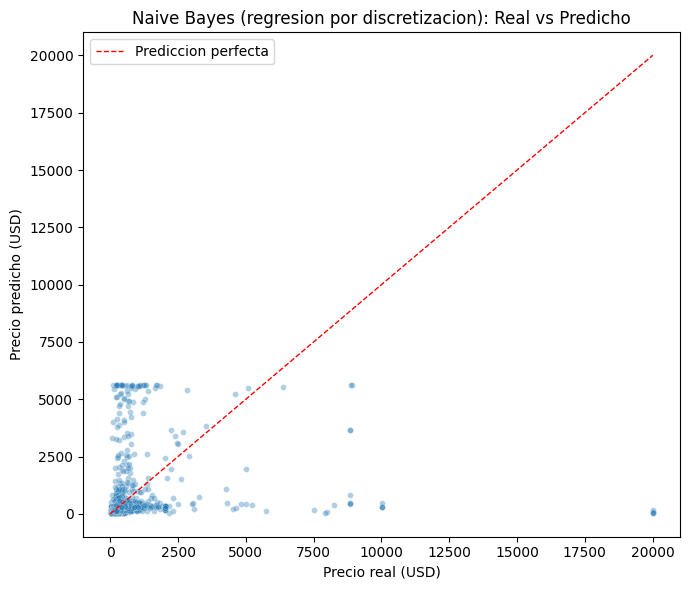

In [57]:
# Actividad 1: se aproxima regresion con Naive Bayes discretizando el target
# GaussianNB clasifica, por eso se convierte log_price en intervalos (bins)
n_bins = 10
y_train_bin, bin_edges = pd.qcut(
    y_train,
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates='drop'
 )
y_train_bin = pd.Series(y_train_bin, index=y_train.index).astype(int)

modelo_nb_reg = GaussianNB()
modelo_nb_reg.fit(X_train, y_train_bin)

# Se reconstruye una prediccion continua usando el valor esperado de los bins
proba_test = modelo_nb_reg.predict_proba(X_test)
bin_centers = {
    i: (bin_edges[i] + bin_edges[i + 1]) / 2
    for i in range(len(bin_edges) - 1)
}
centers_ordered = np.array([bin_centers[int(cls)] for cls in modelo_nb_reg.classes_])
y_pred_log_nb = proba_test @ centers_ordered

# Metricas en escala log
r2_nb_log = r2_score(y_test, y_pred_log_nb)
mae_nb_log = mean_absolute_error(y_test, y_pred_log_nb)
rmse_nb_log = np.sqrt(mean_squared_error(y_test, y_pred_log_nb))

# Metricas en dolares (escala original)
y_test_usd = np.exp(y_test)
y_pred_usd_nb = np.exp(y_pred_log_nb)
mae_nb_usd = mean_absolute_error(y_test_usd, y_pred_usd_nb)
rmse_nb_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_nb))
mape_nb = np.mean(np.abs((y_test_usd - y_pred_usd_nb) / y_test_usd)) * 100

# Baseline simple: se predice la mediana del train
baseline_log = np.full(len(y_test), y_train.median())
baseline_usd = np.exp(baseline_log)
r2_baseline_log = r2_score(y_test, baseline_log)
mae_baseline_usd = mean_absolute_error(y_test_usd, baseline_usd)
rmse_baseline_usd = np.sqrt(mean_squared_error(y_test_usd, baseline_usd))

# Como referencia, tambien se compara con BayesianRidge
modelo_bayes_reg = BayesianRidge()
modelo_bayes_reg.fit(X_train, y_train)
y_pred_log_bayes_ridge = modelo_bayes_reg.predict(X_test)
r2_bayes_ridge_log = r2_score(y_test, y_pred_log_bayes_ridge)
mae_bayes_ridge_usd = mean_absolute_error(y_test_usd, np.exp(y_pred_log_bayes_ridge))
rmse_bayes_ridge_usd = np.sqrt(mean_squared_error(y_test_usd, np.exp(y_pred_log_bayes_ridge)))

resultados = pd.DataFrame({
    'Modelo': [
        'Naive Bayes (discretizado)',
        'Bayesian Ridge (referencia)',
        'Baseline (mediana de train)'
    ],
    'R2_log': [r2_nb_log, r2_bayes_ridge_log, r2_baseline_log],
    'MAE_USD': [mae_nb_usd, mae_bayes_ridge_usd, mae_baseline_usd],
    'RMSE_USD': [rmse_nb_usd, rmse_bayes_ridge_usd, rmse_baseline_usd]
}).set_index('Modelo')

print('Resumen de metricas (menor MAE/RMSE y mayor R2 es mejor):')
print(resultados.round(4))

improv_mae_vs_base = (mae_baseline_usd - mae_nb_usd) / mae_baseline_usd * 100
improv_rmse_vs_base = (rmse_baseline_usd - rmse_nb_usd) / rmse_baseline_usd * 100

print('\nAnalisis Actividad 2:')
print(f'- Naive Bayes (discretizado) R2 en log_price: {r2_nb_log:.4f}')
print(f'- Naive Bayes MAE: ${mae_nb_usd:,.2f} | RMSE: ${rmse_nb_usd:,.2f} | MAPE: {mape_nb:.2f}%')
print(f'- Mejora vs baseline en MAE: {improv_mae_vs_base:.2f}%')
print(f'- Mejora vs baseline en RMSE: {improv_rmse_vs_base:.2f}%')

# Grafico real vs predicho (se recorta al p99 para que no se aplaste la nube)
plot_df = pd.DataFrame({
    'Real_USD': y_test_usd.values,
    'Pred_USD': y_pred_usd_nb
})
upper = np.percentile(plot_df['Real_USD'], 99)
plot_df = plot_df[(plot_df['Real_USD'] <= upper) & (plot_df['Pred_USD'] <= upper)]
plot_df = plot_df.sample(min(3000, len(plot_df)), random_state=42)

plt.figure(figsize=(7, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=18)
plt.plot([0, upper], [0, upper], 'r--', linewidth=1, label='Prediccion perfecta')
plt.title('Naive Bayes (regresion por discretizacion): Real vs Predicho')
plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()

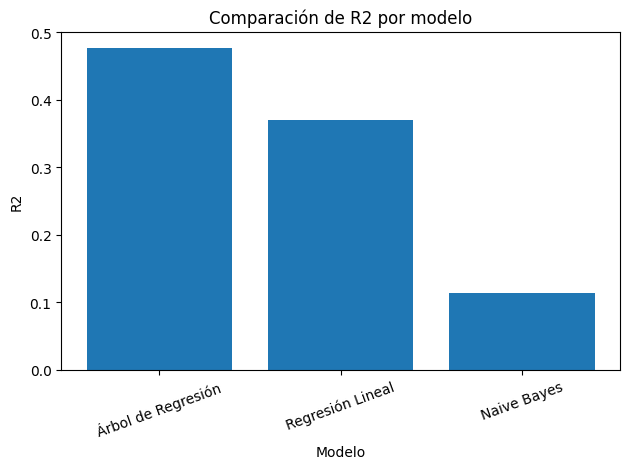

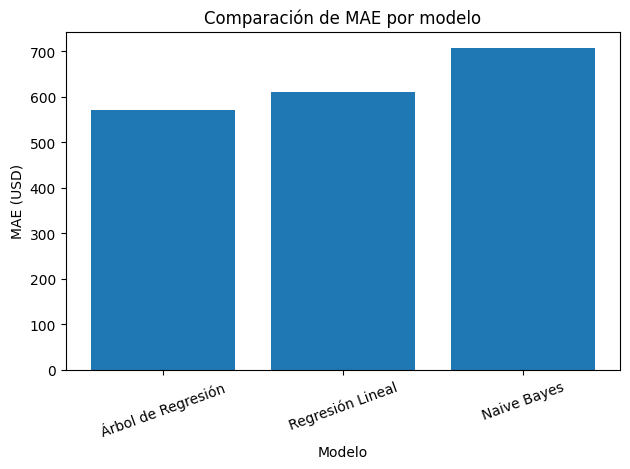

In [58]:
# Gráfica de comparación de modelos 

# Estos datos salen del resultado de Naive Bayes que realizamos en este laboratorio, y los obtenidos en laboratorios anteriores.
data = {
    'Modelo': ['Árbol de Regresión', 'Regresión Lineal', 'Naive Bayes'],
    'R2': [0.4769, 0.3705, 0.1142],
    'MAE': [571.06, 610.96, 707.69]
}

df_comp = pd.DataFrame(data)

# Grafica R2
plt.figure()
plt.bar(df_comp['Modelo'], df_comp['R2'])
plt.title('Comparación de R2 por modelo')
plt.xlabel('Modelo')
plt.ylabel('R2')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Grafica MAE
plt.figure()
plt.bar(df_comp['Modelo'], df_comp['MAE'])
plt.title('Comparación de MAE por modelo')
plt.xlabel('Modelo')
plt.ylabel('MAE (USD)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

4. Haga un modelo de clasificación, use la variable categórica que hizo con el precio de los alquileres de las casas (barata, media y cara) como variable respuesta.

Puntos de corte seleccionados para la variable respuesta:
- Económica (barata): price <= $141.00
- Intermedia (media): $141.00 < price <= $264.00
- Cara: price > $264.00

Distribución de la nueva variable respuesta:
- Económica: 25185 observaciones (33.03%)
- Intermedia: 25164 observaciones (33.00%)
- Cara: 25897 observaciones (33.97%)

Predictores utilizados para clasificación:
['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

Filas de entrenamiento: 60996 | Filas de prueba: 15250
Se reutilizó el mismo split que en regresión: True


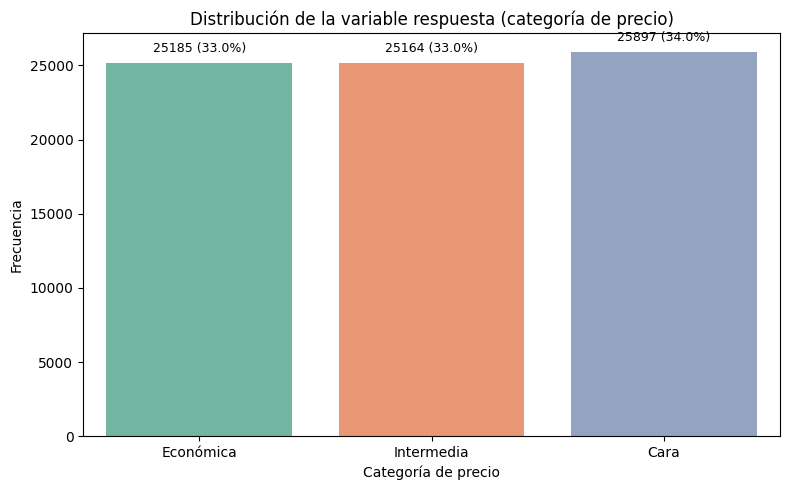

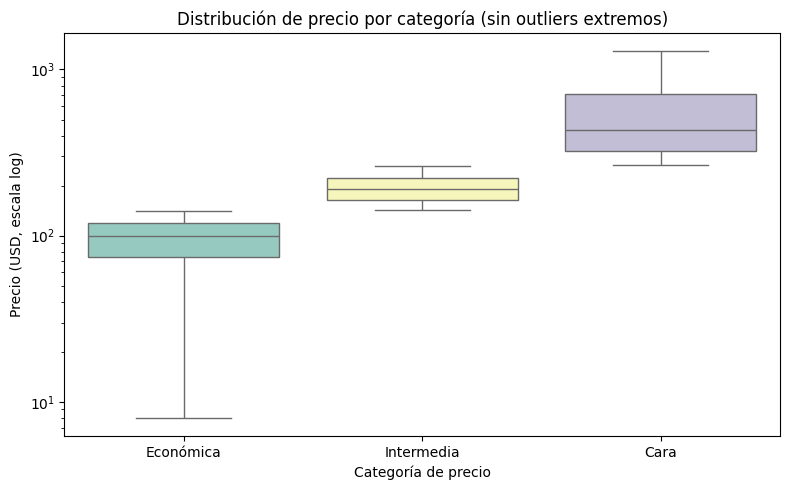

In [59]:
# Actividad 4: clasificacion con Naive Bayes usando la variable categorica de precio
limites = df_model['price'].quantile([0.33, 0.66]).values
p33, p66 = limites[0], limites[1]

def definir_segmento(precio):
    if precio <= p33:
        return 'Económica'
    elif precio <= p66:
        return 'Intermedia'
    return 'Cara'

df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)

features_clas = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'number_of_reviews',
    'review_scores_rating'
]

for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

X_clas = df_model[features_clas].copy()

if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X_clas = pd.concat([X_clas, room_type_dummies], axis=1)

X_clas = X_clas.fillna(X_clas.median(numeric_only=True))
y_clas = df_model['categoria_precio'].copy()

# Se reutiliza exactamente el mismo split del modelo de regresion
train_idx = X_train.index
test_idx = X_test.index

X_train_c = X_clas.loc[train_idx].copy()
X_test_c = X_clas.loc[test_idx].copy()
y_train_c = y_clas.loc[train_idx].copy()
y_test_c = y_clas.loc[test_idx].copy()

labels_orden = ['Económica', 'Intermedia', 'Cara']
modelo_nb_clas = GaussianNB()
modelo_nb_clas.fit(X_train_c, y_train_c)
y_pred_c = modelo_nb_clas.predict(X_test_c)

distribucion_categorias = df_model['categoria_precio'].value_counts().reindex(labels_orden)
distribucion_pct = (df_model['categoria_precio'].value_counts(normalize=True).reindex(labels_orden) * 100).round(2)
split_consistente = X_train_c.index.equals(train_idx) and X_test_c.index.equals(test_idx)

print('Puntos de corte seleccionados para la variable respuesta:')
print(f'- Económica (barata): price <= ${p33:.2f}')
print(f'- Intermedia (media): ${p33:.2f} < price <= ${p66:.2f}')
print(f'- Cara: price > ${p66:.2f}')
print('\nDistribución de la nueva variable respuesta:')
for categoria in labels_orden:
    print(f'- {categoria}: {int(distribucion_categorias[categoria])} observaciones ({distribucion_pct[categoria]:.2f}%)')
print('\nPredictores utilizados para clasificación:')
print(X_clas.columns.tolist())
print(f'\nFilas de entrenamiento: {X_train_c.shape[0]} | Filas de prueba: {X_test_c.shape[0]}')
print(f'Se reutilizó el mismo split que en regresión: {split_consistente}')

# Visualizacion 1: distribucion de categorias del target
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_model,
    x='categoria_precio',
    hue='categoria_precio',
    order=labels_orden,
    palette='Set2',
    legend=False
)
max_count = distribucion_categorias.max()
for i, categoria in enumerate(labels_orden):
    n_cat = int(distribucion_categorias.loc[categoria])
    pct_cat = float(distribucion_pct.loc[categoria])
    ax.text(i, n_cat + max_count * 0.02, f'{n_cat} ({pct_cat:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.title('Distribución de la variable respuesta (categoría de precio)')
plt.xlabel('Categoría de precio')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Visualizacion 2: dispersion del precio real por categoria (escala log)
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_model,
    x='categoria_precio',
    y='price',
    hue='categoria_precio',
    order=labels_orden,
    showfliers=False,
    dodge=False,
    palette='Set3',
    legend=False
)
plt.yscale('log')
plt.title('Distribución de precio por categoría (sin outliers extremos)')
plt.xlabel('Categoría de precio')
plt.ylabel('Precio (USD, escala log)')
plt.tight_layout()
plt.show()

5. Utilice los modelos con el conjunto de prueba y determine la eficiencia del algoritmo para predecir y clasificar.

In [60]:
# Actividad 5: evaluacion del modelo de clasificacion en el conjunto de prueba
accuracy_clas = accuracy_score(y_test_c, y_pred_c)
reporte_clas = pd.DataFrame(
    classification_report(y_test_c, y_pred_c, labels=labels_orden, output_dict=True)
).transpose()
baseline_mayoritaria = y_test_c.value_counts(normalize=True).max()

tabla_4_word = pd.DataFrame([
    {'Métrica': 'Accuracy', 'Valor': accuracy_clas},
    {'Métrica': 'Precisión macro', 'Valor': reporte_clas.loc['macro avg', 'precision']},
    {'Métrica': 'Recall macro', 'Valor': reporte_clas.loc['macro avg', 'recall']},
    {'Métrica': 'F1 macro', 'Valor': reporte_clas.loc['macro avg', 'f1-score']},
    {'Métrica': 'Baseline clase mayoritaria', 'Valor': baseline_mayoritaria}
])

tabla_5_word = reporte_clas.loc[labels_orden, ['precision', 'recall', 'f1-score', 'support']].copy()
tabla_5_word.index.name = 'Categoría'

categoria_mejor = tabla_5_word['f1-score'].idxmax()
categoria_mas_dificil = tabla_5_word['f1-score'].idxmin()

print('Tabla 4. Métricas globales del modelo de clasificación Naive Bayes:')
print(tabla_4_word.round(4).to_string(index=False))
print('\nTabla 5. Desempeño por categoría de precio del modelo Naive Bayes:')
print(tabla_5_word.round(4).to_string())
print('\nAnálisis Actividad 5:')
print(f'- Accuracy en prueba: {accuracy_clas:.4f}')
print(f'- Baseline de la clase mayoritaria: {baseline_mayoritaria:.4f}')
print(f'- Categoría con mejor F1-score: {categoria_mejor} ({tabla_5_word.loc[categoria_mejor, "f1-score"]:.4f})')
print(f'- Categoría más difícil según F1-score: {categoria_mas_dificil} ({tabla_5_word.loc[categoria_mas_dificil, "f1-score"]:.4f})')

Tabla 4. Métricas globales del modelo de clasificación Naive Bayes:
                   Métrica  Valor
                  Accuracy 0.5221
           Precisión macro 0.6215
              Recall macro 0.5205
                  F1 macro 0.5115
Baseline clase mayoritaria 0.3371

Tabla 5. Desempeño por categoría de precio del modelo Naive Bayes:
            precision  recall  f1-score  support
Categoría                                       
Económica      0.6829  0.3357    0.4502   4983.0
Intermedia     0.4167  0.8174    0.5520   5126.0
Cara           0.7649  0.4083    0.5324   5141.0

Análisis Actividad 5:
- Accuracy en prueba: 0.5221
- Baseline de la clase mayoritaria: 0.3371
- Categoría con mejor F1-score: Intermedia (0.5520)
- Categoría más difícil según F1-score: Económica (0.4502)


6. Haga un análisis de la eficiencia del modelo de clasificación usando una matriz de confusión. Tenga en cuenta la efectividad, donde el algoritmo se equivocó más, donde se equivocó menos y la importancia que tienen los errores.

Análisis Actividad 6 (matriz de confusión):
- Efectividad global (1 - tasa de error): 0.5221
- Mayor efectividad por clase (recall): Intermedia (0.8174)
- Menor efectividad por clase (recall): Económica (0.3357)
- Dónde el algoritmo se equivocó más (clase real): Económica con 3310 errores
- Dónde el algoritmo se equivocó menos (clase real): Intermedia con 936 errores
- Confusión más frecuente: Real='Económica' y Predicho='Intermedia' con 3146 casos
- Errores moderados (entre clases vecinas): 6802
- Errores críticos (Económica <-> Cara): 486
- Índice de gravedad del error [0,1]: 0.5333
  (valores cercanos a 1 implican mayor proporción de errores críticos)


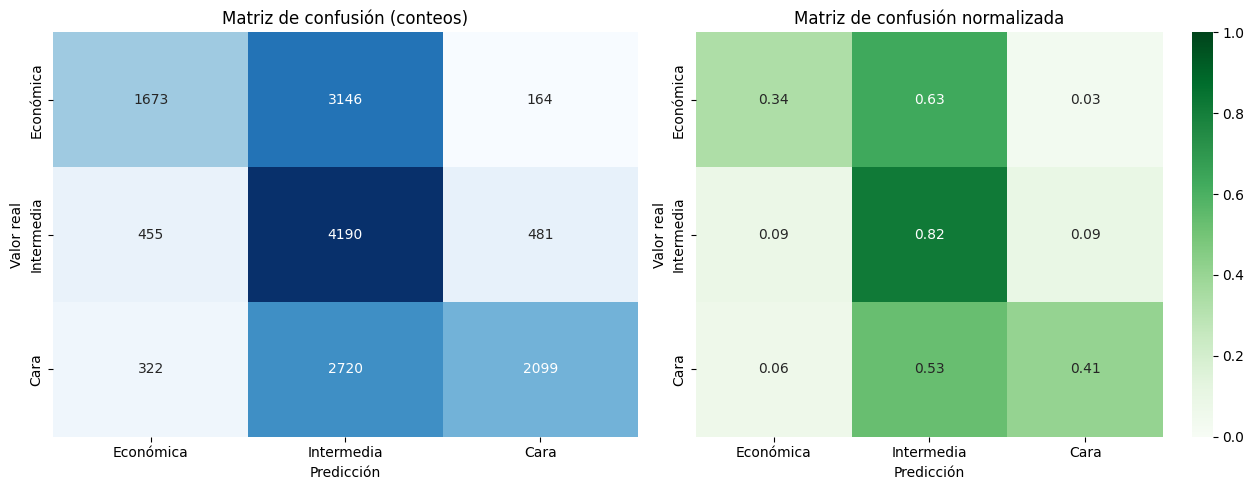

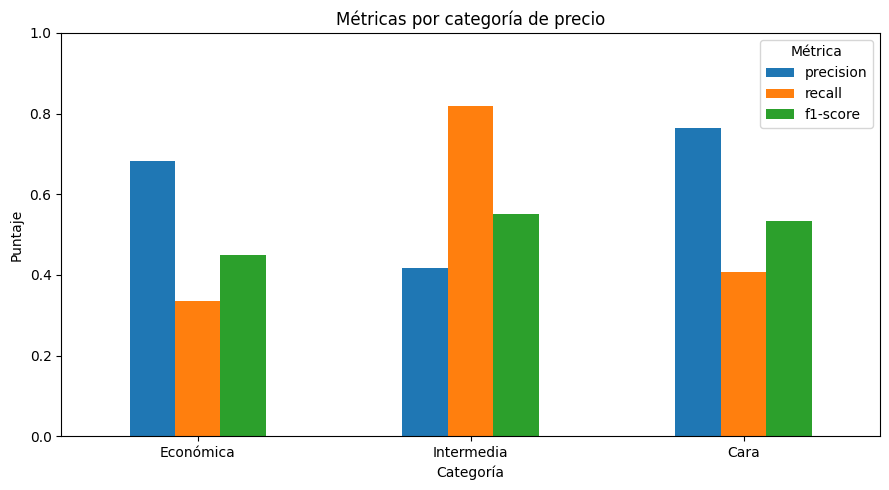

In [61]:
# Actividad 6: analisis de eficiencia con matriz de confusion

if 'tabla_5_word' not in locals():
    _reporte_tmp = pd.DataFrame(
        classification_report(y_test_c, y_pred_c, labels=labels_orden, output_dict=True)
    ).transpose()
    tabla_5_word = _reporte_tmp.loc[labels_orden, ['precision', 'recall', 'f1-score', 'support']].copy()
    tabla_5_word.index.name = 'Categoría'

matriz_conf = pd.crosstab(
    y_test_c,
    y_pred_c,
    rownames=['Real'],
    colnames=['Predicho'],
    dropna=False
).reindex(index=labels_orden, columns=labels_orden, fill_value=0)

matriz_conf_norm = matriz_conf.div(matriz_conf.sum(axis=1).replace(0, np.nan), axis=0)

# Resumen cuantitativo de errores para interpretar donde falla mas/menos
errores_fuera_diag = matriz_conf.copy()
for categoria in errores_fuera_diag.index.intersection(errores_fuera_diag.columns):
    errores_fuera_diag.loc[categoria, categoria] = 0

total_obs = int(matriz_conf.to_numpy().sum())
total_errores = int(errores_fuera_diag.to_numpy().sum())
efectividad_global = 1 - (total_errores / total_obs if total_obs else 0)

errores_por_clase_real = errores_fuera_diag.sum(axis=1).sort_values(ascending=False)
clase_donde_falla_mas = errores_por_clase_real.index[0]
n_falla_mas = int(errores_por_clase_real.iloc[0])
clase_donde_falla_menos = errores_por_clase_real.index[-1]
n_falla_menos = int(errores_por_clase_real.iloc[-1])

if total_errores > 0:
    par_mas_confundido = errores_fuera_diag.stack().idxmax()
    n_par_mas_confundido = int(errores_fuera_diag.stack().max())
else:
    par_mas_confundido = ('N/A', 'N/A')
    n_par_mas_confundido = 0

# Importancia de errores: confundir extremos (Económica <-> Cara) se considera mas grave
errores_criticos = 0
if 'Económica' in labels_orden and 'Cara' in labels_orden:
    errores_criticos = int(
        errores_fuera_diag.loc['Económica', 'Cara'] +
        errores_fuera_diag.loc['Cara', 'Económica']
    )
errores_moderados = total_errores - errores_criticos

# Indice simple en [0,1]: pondera doble los errores criticos
indice_gravedad = (
    (2 * errores_criticos + errores_moderados) / (2 * total_errores)
    if total_errores > 0 else 0
)

categoria_mejor_recall = tabla_5_word['recall'].idxmax()
categoria_peor_recall = tabla_5_word['recall'].idxmin()

print('Análisis Actividad 6 (matriz de confusión):')
print(f'- Efectividad global (1 - tasa de error): {efectividad_global:.4f}')
print(f'- Mayor efectividad por clase (recall): {categoria_mejor_recall} ({tabla_5_word.loc[categoria_mejor_recall, "recall"]:.4f})')
print(f'- Menor efectividad por clase (recall): {categoria_peor_recall} ({tabla_5_word.loc[categoria_peor_recall, "recall"]:.4f})')
print(f'- Dónde el algoritmo se equivocó más (clase real): {clase_donde_falla_mas} con {n_falla_mas} errores')
print(f'- Dónde el algoritmo se equivocó menos (clase real): {clase_donde_falla_menos} con {n_falla_menos} errores')
if total_errores > 0:
    print(
        f"- Confusión más frecuente: Real='{par_mas_confundido[0]}' y Predicho='{par_mas_confundido[1]}' "
        f"con {n_par_mas_confundido} casos"
    )
else:
    print('- No hubo errores de clasificación en el conjunto de prueba')
print(f'- Errores moderados (entre clases vecinas): {errores_moderados}')
print(f'- Errores críticos (Económica <-> Cara): {errores_criticos}')
print(f'- Índice de gravedad del error [0,1]: {indice_gravedad:.4f}')
print('  (valores cercanos a 1 implican mayor proporción de errores críticos)')

# Visualizacion 1: matriz de confusion (conteos y proporcion por fila)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Matriz de confusión (conteos)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor real')

sns.heatmap(matriz_conf_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title('Matriz de confusión normalizada')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Valor real')

plt.tight_layout()
plt.show()

# Visualizacion 2: precision, recall y F1-score por categoria
tabla_metricas_plot = tabla_5_word[['precision', 'recall', 'f1-score']].copy()
ax = tabla_metricas_plot.plot(kind='bar', figsize=(9, 5), rot=0)
ax.set_title('Métricas por categoría de precio')
ax.set_xlabel('Categoría')
ax.set_ylabel('Puntaje')
ax.set_ylim(0, 1)
plt.legend(title='Métrica')
plt.tight_layout()
plt.show()

7. Analice el modelo. ¿Cree que pueda estar sobreajustado?

Comparación de desempeño: Train vs Test
       Accuracy  Precisión macro  Recall macro  F1 macro
Train    0.5162           0.6196        0.5180    0.5079
Test     0.5221           0.6215        0.5205    0.5115


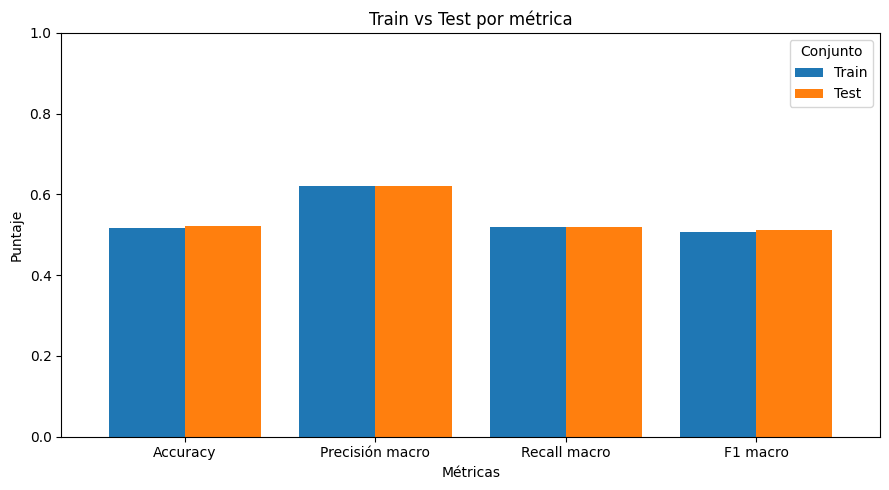


Interpretación:
- Señal de underfitting: Train y Test son parecidos, pero ambos muestran desempeño relativamente bajo.

Resumen técnico: gap_accuracy = -0.0059, gap_f1_macro = -0.0036


In [62]:
# Actividad 7: analisis de posible sobreajuste (overfitting) en Naive Bayes

# Se usa el modelo ya entrenado.
y_pred_train = modelo_nb_clas.predict(X_train_c)
y_pred_test = modelo_nb_clas.predict(X_test_c)

# Reportes para extraer métricas macro
reporte_train = classification_report(
    y_train_c, y_pred_train, labels=labels_orden, output_dict=True, zero_division=0
)
reporte_test = classification_report(
    y_test_c, y_pred_test, labels=labels_orden, output_dict=True, zero_division=0
)

# Métricas en entrenamiento y prueba
metricas_comparativas = pd.DataFrame({
    'Accuracy': [
        accuracy_score(y_train_c, y_pred_train),
        accuracy_score(y_test_c, y_pred_test)
    ],
    'Precisión macro': [
        reporte_train['macro avg']['precision'],
        reporte_test['macro avg']['precision']
    ],
    'Recall macro': [
        reporte_train['macro avg']['recall'],
        reporte_test['macro avg']['recall']
    ],
    'F1 macro': [
        reporte_train['macro avg']['f1-score'],
        reporte_test['macro avg']['f1-score']
    ]
}, index=['Train', 'Test'])

print('Comparación de desempeño: Train vs Test')
print(metricas_comparativas.round(4).to_string())

# Grafica de barras: eje X = métricas, barras = Train vs Test
metricas_plot = metricas_comparativas.T
ax = metricas_plot.plot(kind='bar', figsize=(9, 5), rot=0, width=0.8)
ax.set_title('Train vs Test por métrica')
ax.set_xlabel('Métricas')
ax.set_ylabel('Puntaje')
ax.set_ylim(0, 1)
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

# Criterios simples para interpretación
f1_train = metricas_comparativas.loc['Train', 'F1 macro']
f1_test = metricas_comparativas.loc['Test', 'F1 macro']
acc_train = metricas_comparativas.loc['Train', 'Accuracy']
acc_test = metricas_comparativas.loc['Test', 'Accuracy']

gap_f1 = f1_train - f1_test
gap_acc = acc_train - acc_test

print('\nInterpretación:')
if (gap_f1 >= 0.08) or (gap_acc >= 0.08):
    print('- Señal de overfitting: el rendimiento en Train es claramente mayor que en Test (train >> test).')
elif (abs(gap_f1) <= 0.05) and (abs(gap_acc) <= 0.05) and (f1_test < 0.60):
    print('- Señal de underfitting: Train y Test son parecidos, pero ambos muestran desempeño relativamente bajo.')
elif (abs(gap_f1) <= 0.05) and (abs(gap_acc) <= 0.05) and (f1_test >= 0.60):
    print('- El modelo parece generalizar bien: Train y Test son similares y ambos relativamente altos.')
else:
    print('- Resultado intermedio: no hay evidencia fuerte de sobreajuste, pero conviene revisar ajuste del modelo.')

print(f'\nResumen técnico: gap_accuracy = {gap_acc:.4f}, gap_f1_macro = {gap_f1:.4f}')

8. Haga un modelo usando validación cruzada, compare los resultados de este con los del modelo anterior. ¿Cuál funcionó mejor?

Resultados de validación cruzada (5 folds):
- Accuracy CV: media = 0.5080, desviación estándar = 0.0312
- F1 macro CV: media = 0.4921, desviación estándar = 0.0421

Tabla comparativa de métricas:
                             Accuracy  F1 macro
Train/Test                     0.5221    0.5115
Cross-validation (promedio)    0.5080    0.4921


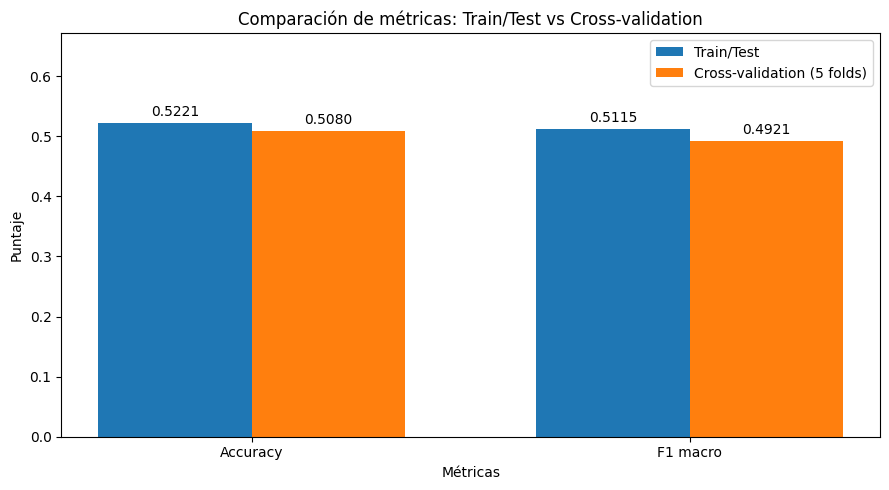

In [63]:
# Actividad 8: validacion cruzada del modelo de clasificacion Naive Bayes

# Se importa la funcion para validacion cruzada.
from sklearn.model_selection import cross_val_score

# Se definen metricas para validacion cruzada con 5 folds.
scores_acc_cv = cross_val_score(
    modelo_nb_clas,
    X_clas,
    y_clas,
    cv=5,
    scoring='accuracy'
 )
scores_f1_cv = cross_val_score(
    modelo_nb_clas,
    X_clas,
    y_clas,
    cv=5,
    scoring='f1_macro'
 )

# Se calculan promedio y desviacion estandar de cada metrica.
acc_cv_mean = scores_acc_cv.mean()
acc_cv_std = scores_acc_cv.std()
f1_cv_mean = scores_f1_cv.mean()
f1_cv_std = scores_f1_cv.std()

print('Resultados de validación cruzada (5 folds):')
print(f'- Accuracy CV: media = {acc_cv_mean:.4f}, desviación estándar = {acc_cv_std:.4f}')
print(f'- F1 macro CV: media = {f1_cv_mean:.4f}, desviación estándar = {f1_cv_std:.4f}')

# Se construye tabla comparativa con valores previos y validacion cruzada.
accuracy_anterior = 0.5221
f1_anterior = 0.5115

tabla_comparativa_cv = pd.DataFrame({
    'Accuracy': [accuracy_anterior, acc_cv_mean],
    'F1 macro': [f1_anterior, f1_cv_mean]
}, index=['Train/Test', 'Cross-validation (promedio)'])

print('\nTabla comparativa de métricas:')
print(tabla_comparativa_cv.round(4).to_string())

# Se grafica comparacion Train/Test vs Cross-validation para ambas metricas.
metricas = ['Accuracy', 'F1 macro']
valores_anterior = [accuracy_anterior, f1_anterior]
valores_cv = [acc_cv_mean, f1_cv_mean]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_anterior = ax.bar(x - width / 2, valores_anterior, width, label='Train/Test')
barras_cv = ax.bar(x + width / 2, valores_cv, width, label='Cross-validation (5 folds)')

ax.set_title('Comparación de métricas: Train/Test vs Cross-validation')
ax.set_xlabel('Métricas')
ax.set_ylabel('Puntaje')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, min(1.0, max(valores_anterior + valores_cv) + 0.15))
ax.legend()

# Se agregan etiquetas para facilitar la interpretacion visual.
ax.bar_label(barras_anterior, fmt='%.4f', padding=3)
ax.bar_label(barras_cv, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()